#### Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


#### Importing Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

#### Taking Path

In [3]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")

#### Loading Dataset

In [4]:
df = pd.read_csv(CSV_PATH)
df. head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


#### EDA

In [ ]:
df.info()
df.describe()

## checking duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

df.iloc[0]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 
 14  O       

,0
ID,0
Patient Age,69
Patient Sex,Female
Left-Fundus,0_left.jpg
Right-Fundus,0_right.jpg
Left-Diagnostic Keywords,cataract
Right-Diagnostic Keywords,normal fundus
N,0
D,0
G,0


##Dataset Summary

In [ ]:
print("="*50)
print("Dataset Summary")
print("="*50)

print(f"Total Images: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"Unique Patients: {df['ID'].nunique()}")

print("\nImage Directory:")
print(TRAIN_DIR)

Dataset Summary
Total Images: 6392
Total Columns: 19
Unique Patients: 3358

Image Directory:
/content/drive/My Drive/Eye Disease/Dataset/ODIR-5K/ODIR-5K/Training Images


##Age Distribution

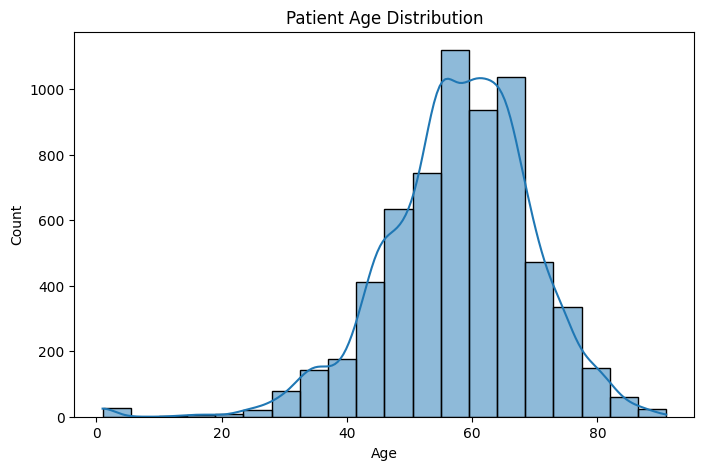

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Patient Age"], bins=20, kde=True)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

##Gender Distribution

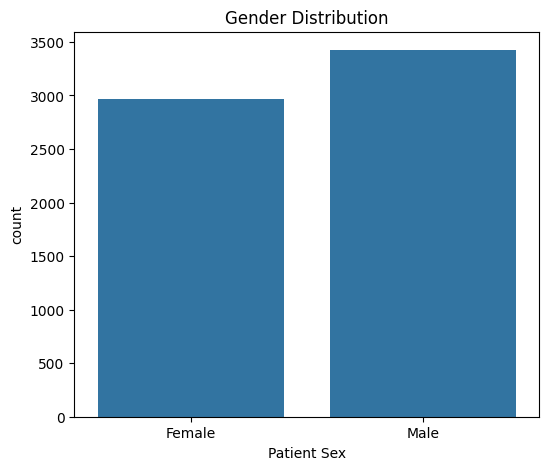

Patient Sex
Male      3424
Female    2968
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Patient Sex")

plt.title("Gender Distribution")

plt.show()

print(df["Patient Sex"].value_counts())

##Disease Distribution

In [ ]:
disease_cols = ['N','D','G','C','A','H','M','O']

disease_counts = df[disease_cols].sum().sort_values(ascending=False)

print(disease_counts)

D    2123
N    2101
O    1588
C     402
G     397
A     319
M     306
H     203
dtype: int64


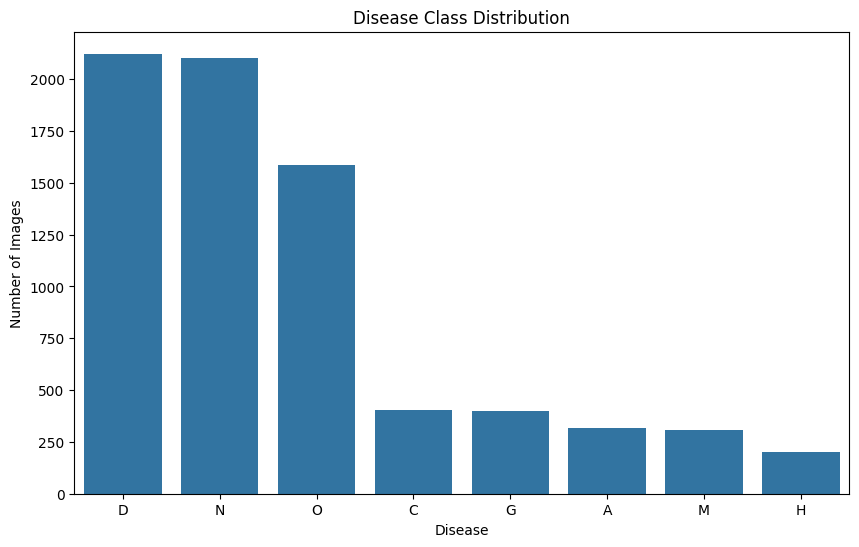

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(x=disease_counts.index,
            y=disease_counts.values)

plt.title("Disease Class Distribution")

plt.xlabel("Disease")

plt.ylabel("Number of Images")

plt.show()

##Disease Percentage

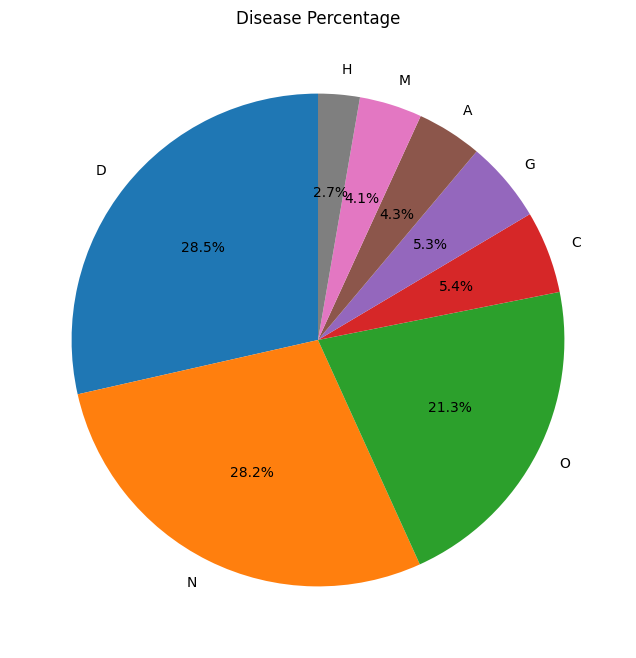

In [ ]:
percent = disease_counts / disease_counts.sum() * 100

plt.figure(figsize=(8,8))

plt.pie(percent,
        labels=percent.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Disease Percentage")

plt.show()

##Imbalance Ratio

In [ ]:
largest = disease_counts.max()

smallest = disease_counts.min()

print("Largest class :", largest)

print("Smallest class:", smallest)

print("Imbalance Ratio:", round(largest/smallest,2))

Largest class : 2123
Smallest class: 203
Imbalance Ratio: 10.46


##Multi-label Distribution

In [ ]:
df["Number_of_Labels"] = df[disease_cols].sum(axis=1)

df["Number_of_Labels"].value_counts()

,count
Number_of_Labels,
1,5391
2,955
3,46


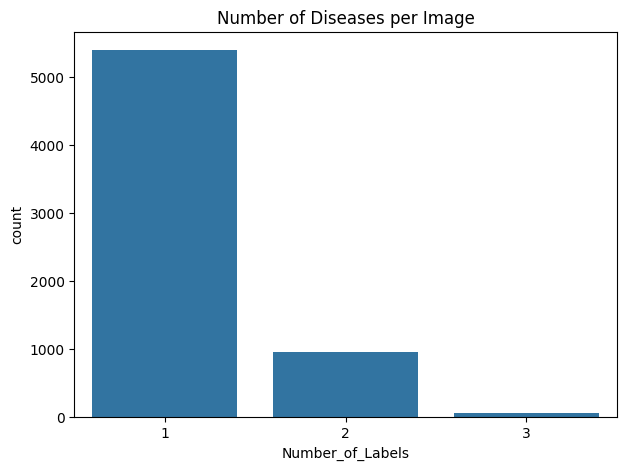

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Number_of_Labels")

plt.title("Number of Diseases per Image")

plt.show()

##Disease Correlation

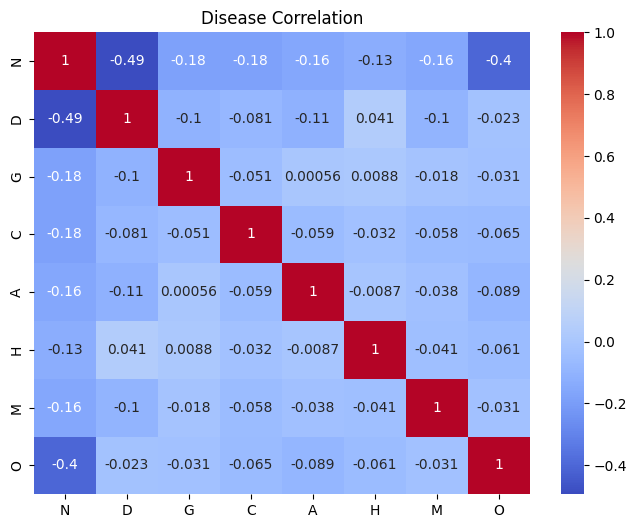

In [ ]:
corr = df[disease_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Disease Correlation")

plt.show()

##Age vs Disease

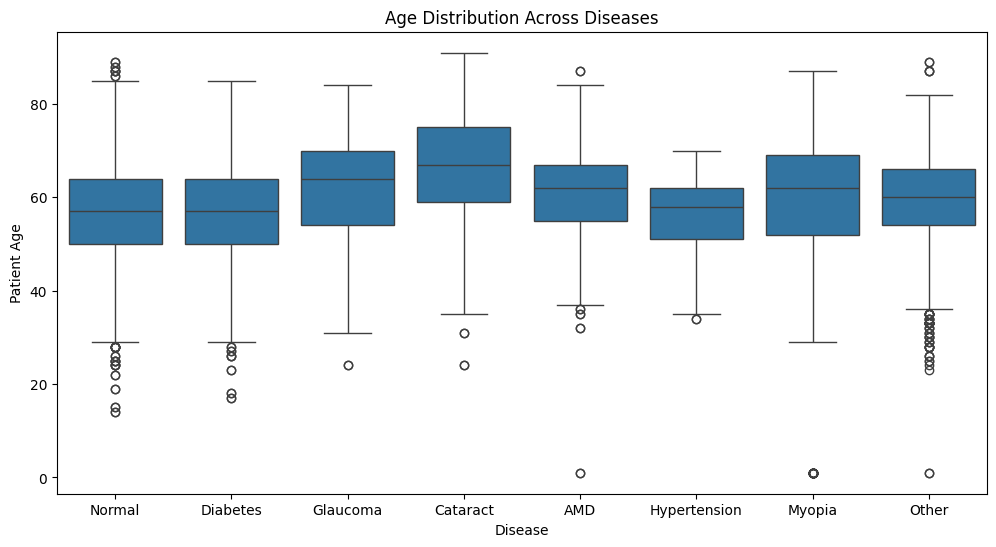

In [ ]:
disease_name = {
'N':'Normal',
'D':'Diabetes',
'G':'Glaucoma',
'C':'Cataract',
'A':'AMD',
'H':'Hypertension',
'M':'Myopia',
'O':'Other'
}

long_df = df.melt(
    id_vars=["Patient Age"],
    value_vars=disease_cols,
    var_name="Disease",
    value_name="Present"
)

long_df = long_df[long_df["Present"]==1]

long_df["Disease"] = long_df["Disease"].map(disease_name)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x="Disease",
    y="Patient Age"
)

plt.title("Age Distribution Across Diseases")

plt.show()

##Gender vs Disease

In [ ]:
gender_disease = pd.crosstab(
    df["Patient Sex"],
    df[disease_cols].idxmax(axis=1)
)

gender_disease.columns = [disease_name[i] for i in gender_disease.columns]

gender_disease

,AMD,Cataract,Diabetes,Glaucoma,Hypertension,Myopia,Normal,Other
Patient Sex,,,,,,,,
Female,126,191,940,142,28,176,927,438
Male,141,131,1183,199,59,81,1174,456


##Heatmap

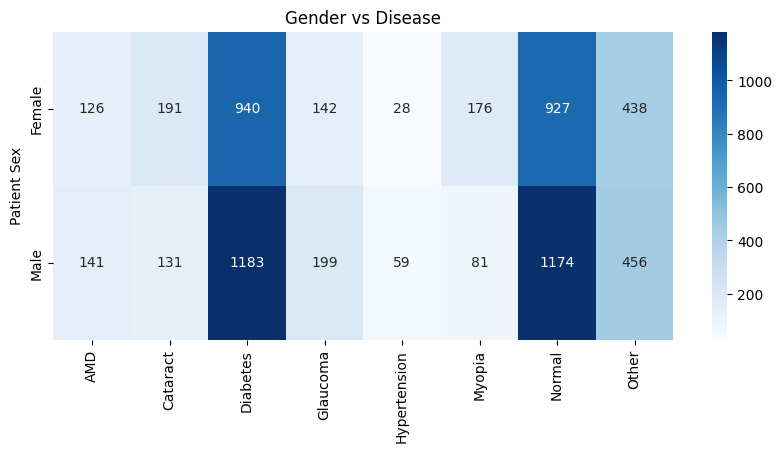

In [ ]:
plt.figure(figsize=(10,4))

sns.heatmap(gender_disease,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Gender vs Disease")

plt.show()

##Display Sample Images

In [ ]:
import os

image_path = os.path.join(TRAIN_DIR, df.iloc[0]["filename"])

print(image_path)
print(os.path.exists(image_path))

/content/drive/My Drive/Eye Disease/Dataset/ODIR-5K/ODIR-5K/Training Images/0_right.jpg
True


In [ ]:
# their is filepath issue so we have apply this
df["filepath"] = df["filename"].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

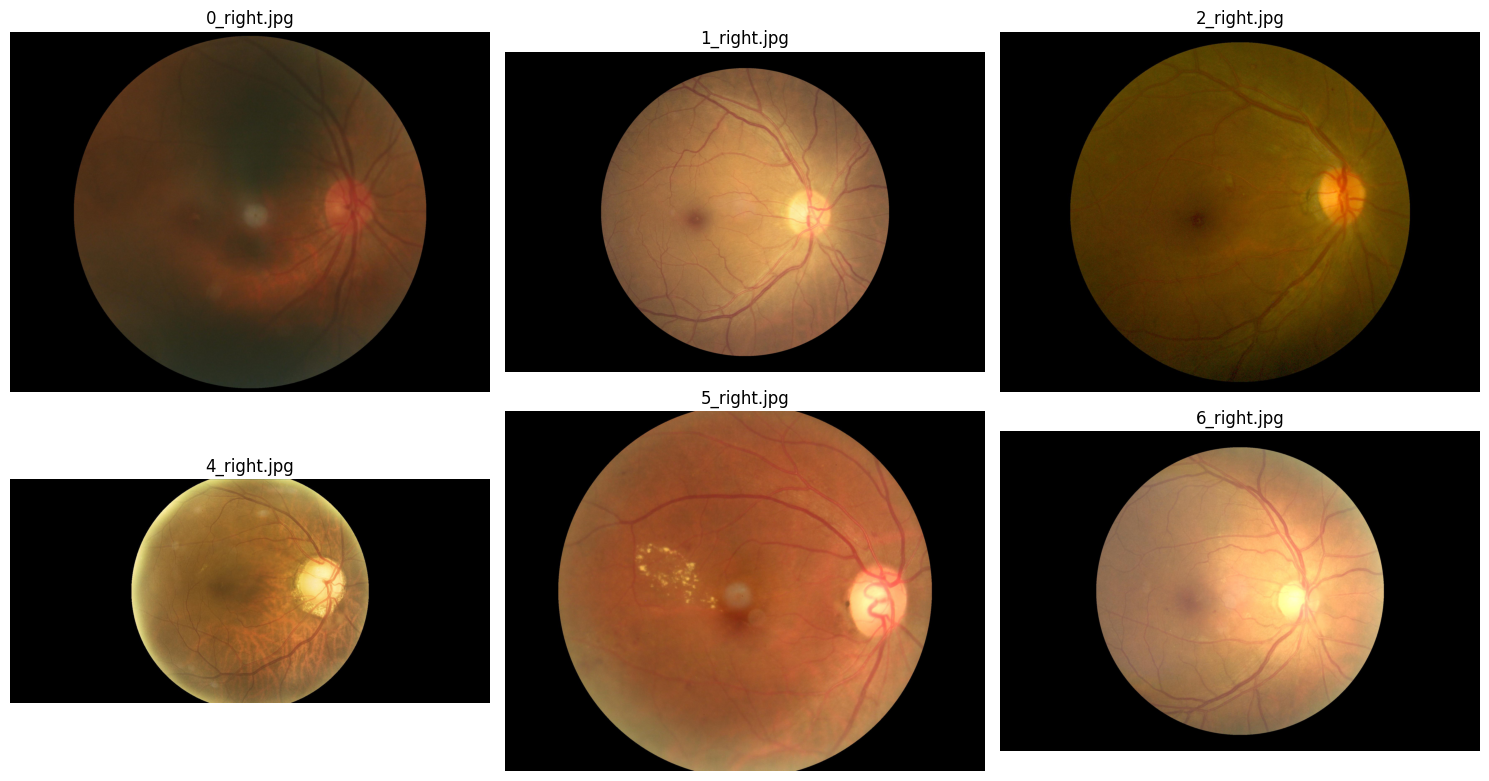

In [ ]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

count = 0

for i in range(len(df)):

    img = cv2.imread(df.iloc[i]["filepath"])

    if img is None:
        print("Cannot read:", df.iloc[i]["filepath"])
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,count+1)
    plt.imshow(img)
    plt.title(df.iloc[i]["filename"])
    plt.axis("off")

    count += 1

    if count == 6:
        break

plt.tight_layout()
plt.show()

##Image Resolution Analysis

In [ ]:
import cv2
from tqdm import tqdm

widths = []
heights = []

for path in tqdm(df["filepath"]):
    img = cv2.imread(path)

    if img is None:
        continue

    h, w = img.shape[:2]

    widths.append(w)
    heights.append(h)

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(widths, heights, alpha=0.4)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")

plt.show()

##Brightness Distribution

In [ ]:
import cv2

brightness = []

for path in df["filepath"]:

    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(gray.mean())

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(brightness,
             bins=30,
             kde=True)

plt.title("Brightness Distribution")

plt.xlabel("Average Brightness")

plt.show()

##Plot Intensity Histogram

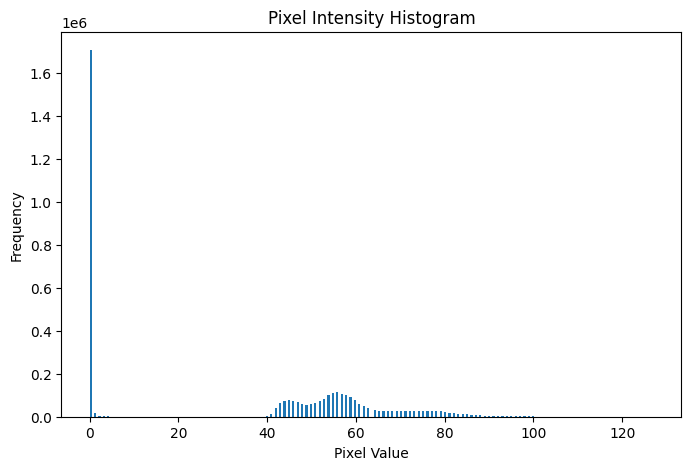

In [ ]:
img = cv2.imread(df.iloc[0]["filepath"])

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,5))

plt.hist(gray.ravel(),
         bins=256)

plt.title("Pixel Intensity Histogram")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

##Sample image for each disease

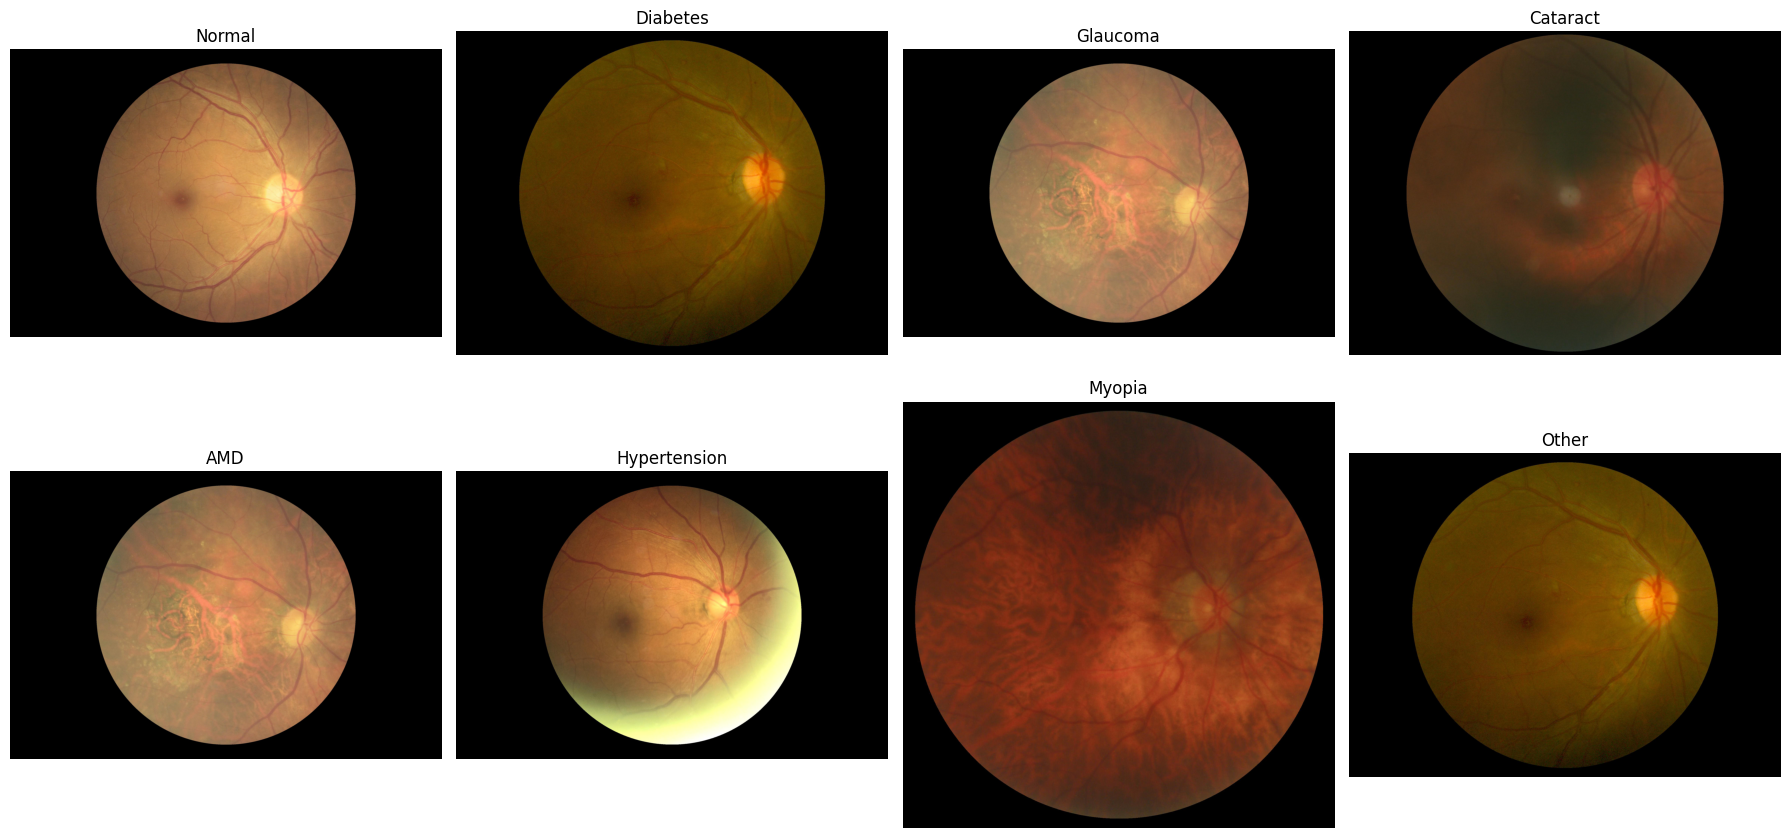

In [ ]:
disease_name = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}

fig, axes = plt.subplots(2,4, figsize=(18,9))

axes = axes.flatten()

for i, col in enumerate(disease_name.keys()):

    sample = df[df[col] == 1].iloc[0]

    img = cv2.imread(sample["filepath"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(disease_name[col], fontsize=12)
    axes[i].axis("off")

plt.tight_layout()

plt.show()

**The original Training Images directory contained 7000 images. However, only the 6392 images referenced in full_df.csv were used for analysis and model development, as these images have complete metadata and disease labels.**

In [ ]:
train_images = df["filename"].tolist()

print("Total labeled images:", len(train_images))

Total labeled images: 6392


##Image counting in each folders

In [ ]:
import os

train_images = os.listdir(TRAIN_DIR)
test_images = os.listdir(TEST_DIR)
preprocess_images = os.listdir(PREPROCESS_DIR)

print("Training Images :", len(train_images))
print("Testing Images  :", len(test_images))
print("Preprocessed Images :", len(preprocess_images))

Training Images : 7000
Testing Images  : 1000
Preprocessed Images : 6392


##Check Missing Images

In [ ]:
missing = []

for file in train_images:

    path = os.path.join(TRAIN_DIR, file)

    if not os.path.exists(path):
        missing.append(file)

print("Missing Images:", len(missing))

Missing Images: 0


##Corrupted Images

In [ ]:
import cv2
from tqdm import tqdm

corrupted = []

for file in tqdm(train_images):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    if img is None:
        corrupted.append(file)

print("Corrupted Images:", len(corrupted))

##Resolution Analysis

In [ ]:
widths = []
heights = []

for file in tqdm(train_images):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    if img is None:
        continue

    h, w = img.shape[:2]

    widths.append(w)
    heights.append(h)

resolution_df = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

resolution_df.describe()

##Unique Resolutions

In [ ]:
resolution_df["Resolution"] = (
    resolution_df["Width"].astype(str)
    + " × "
    + resolution_df["Height"].astype(str)
)

resolution_df["Resolution"].value_counts()

##Brightness Distribution

In [ ]:
brightness = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    brightness.append(img.mean())

plt.figure(figsize=(8,5))

sns.histplot(brightness, bins=30, kde=True)

plt.title("Brightness Distribution")
plt.show()

##Contrast Distribution

In [ ]:
contrast = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    contrast.append(img.std())

plt.figure(figsize=(8,5))

plt.hist(contrast, bins=30)

plt.title("Contrast Distribution")

plt.show()

##Sharpness Distribution

In [ ]:
def laplacian_variance(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

sharpness = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    sharpness.append(laplacian_variance(img))

plt.figure(figsize=(8,5))

plt.hist(sharpness, bins=30)

plt.title("Sharpness Distribution")

plt.show()

##RGB Channel Statistics

In [ ]:
rgb_mean = []

for file in tqdm(train_images[:300]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    rgb_mean.append(img.mean(axis=(0,1)))

rgb_mean = np.array(rgb_mean)

plt.figure(figsize=(10,5))

plt.plot(rgb_mean[:,0], label="Red")
plt.plot(rgb_mean[:,1], label="Green")
plt.plot(rgb_mean[:,2], label="Blue")

plt.legend()

plt.title("RGB Channel Means")

plt.show()

##Display Original vs Preprocessed

In [ ]:
train_set = set(os.listdir(TRAIN_DIR))
prep_set = set(os.listdir(PREPROCESS_DIR))

common = train_set & prep_set
missing = train_set - prep_set
extra = prep_set - train_set

print("Training images:", len(train_set))
print("Preprocessed images:", len(prep_set))
print("Matching filenames:", len(common))
print("Missing from preprocessing:", len(missing))
print("Extra files:", len(extra))

print("\nFirst 10 missing:")
print(list(missing)[:10])

Training images: 7000
Preprocessed images: 6392
Matching filenames: 6392
Missing from preprocessing: 608
Extra files: 0

First 10 missing:
['1242_left.jpg', '39_right.jpg', '3022_right.jpg', '1208_left.jpg', '438_left.jpg', '811_right.jpg', '188_left.jpg', '3325_right.jpg', '994_right.jpg', '1643_right.jpg']


Common files: 6392


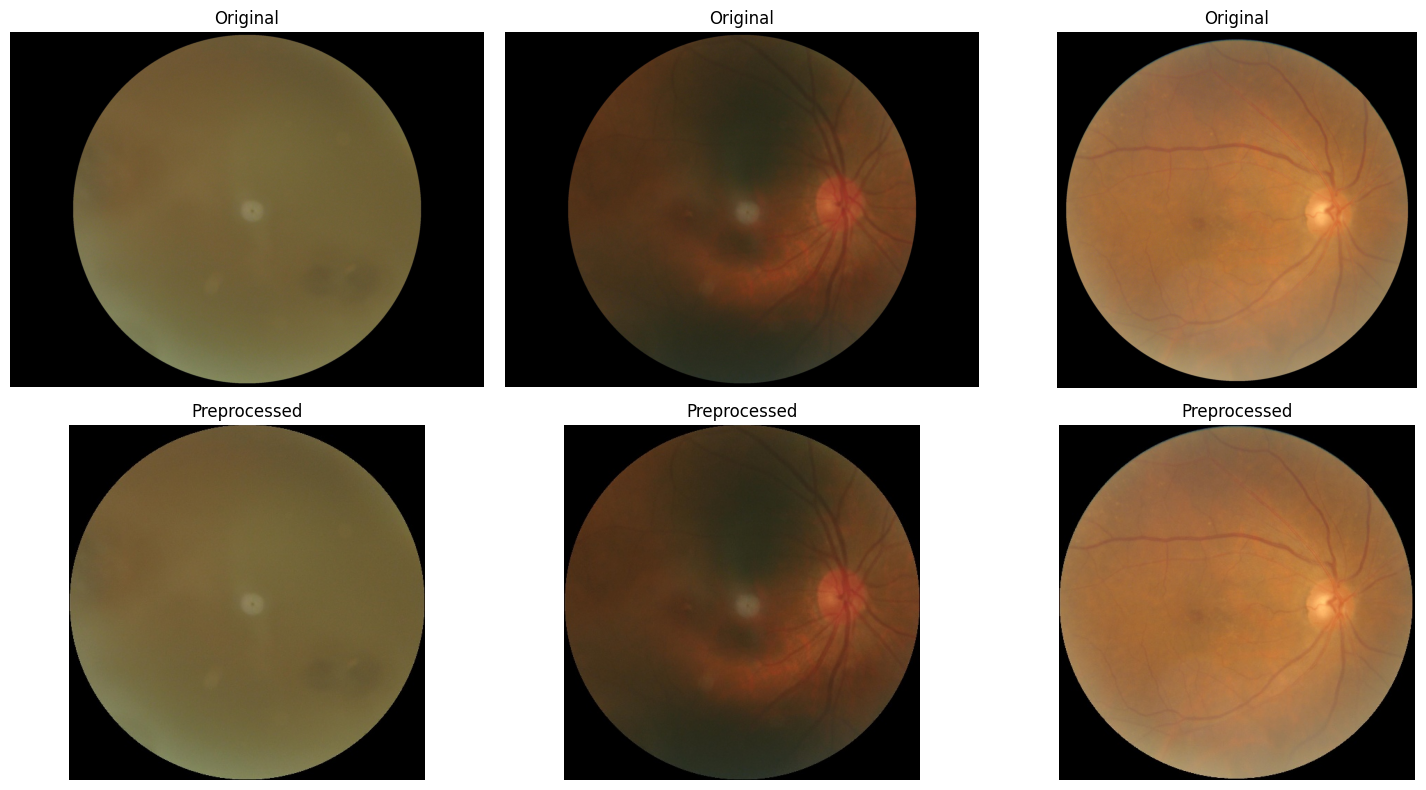

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

common_files = sorted(
    list(set(os.listdir(TRAIN_DIR)) & set(os.listdir(PREPROCESS_DIR)))
)

print("Common files:", len(common_files))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, file in enumerate(common_files[:3]):

    original = cv2.imread(os.path.join(TRAIN_DIR, file))
    processed = cv2.imread(os.path.join(PREPROCESS_DIR, file))

    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    ax[0, i].imshow(original)
    ax[0, i].set_title("Original")
    ax[0, i].axis("off")

    ax[1, i].imshow(processed)
    ax[1, i].set_title("Preprocessed")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()

##Disease-wise Gallery(displaying 3 images from each disease classes)

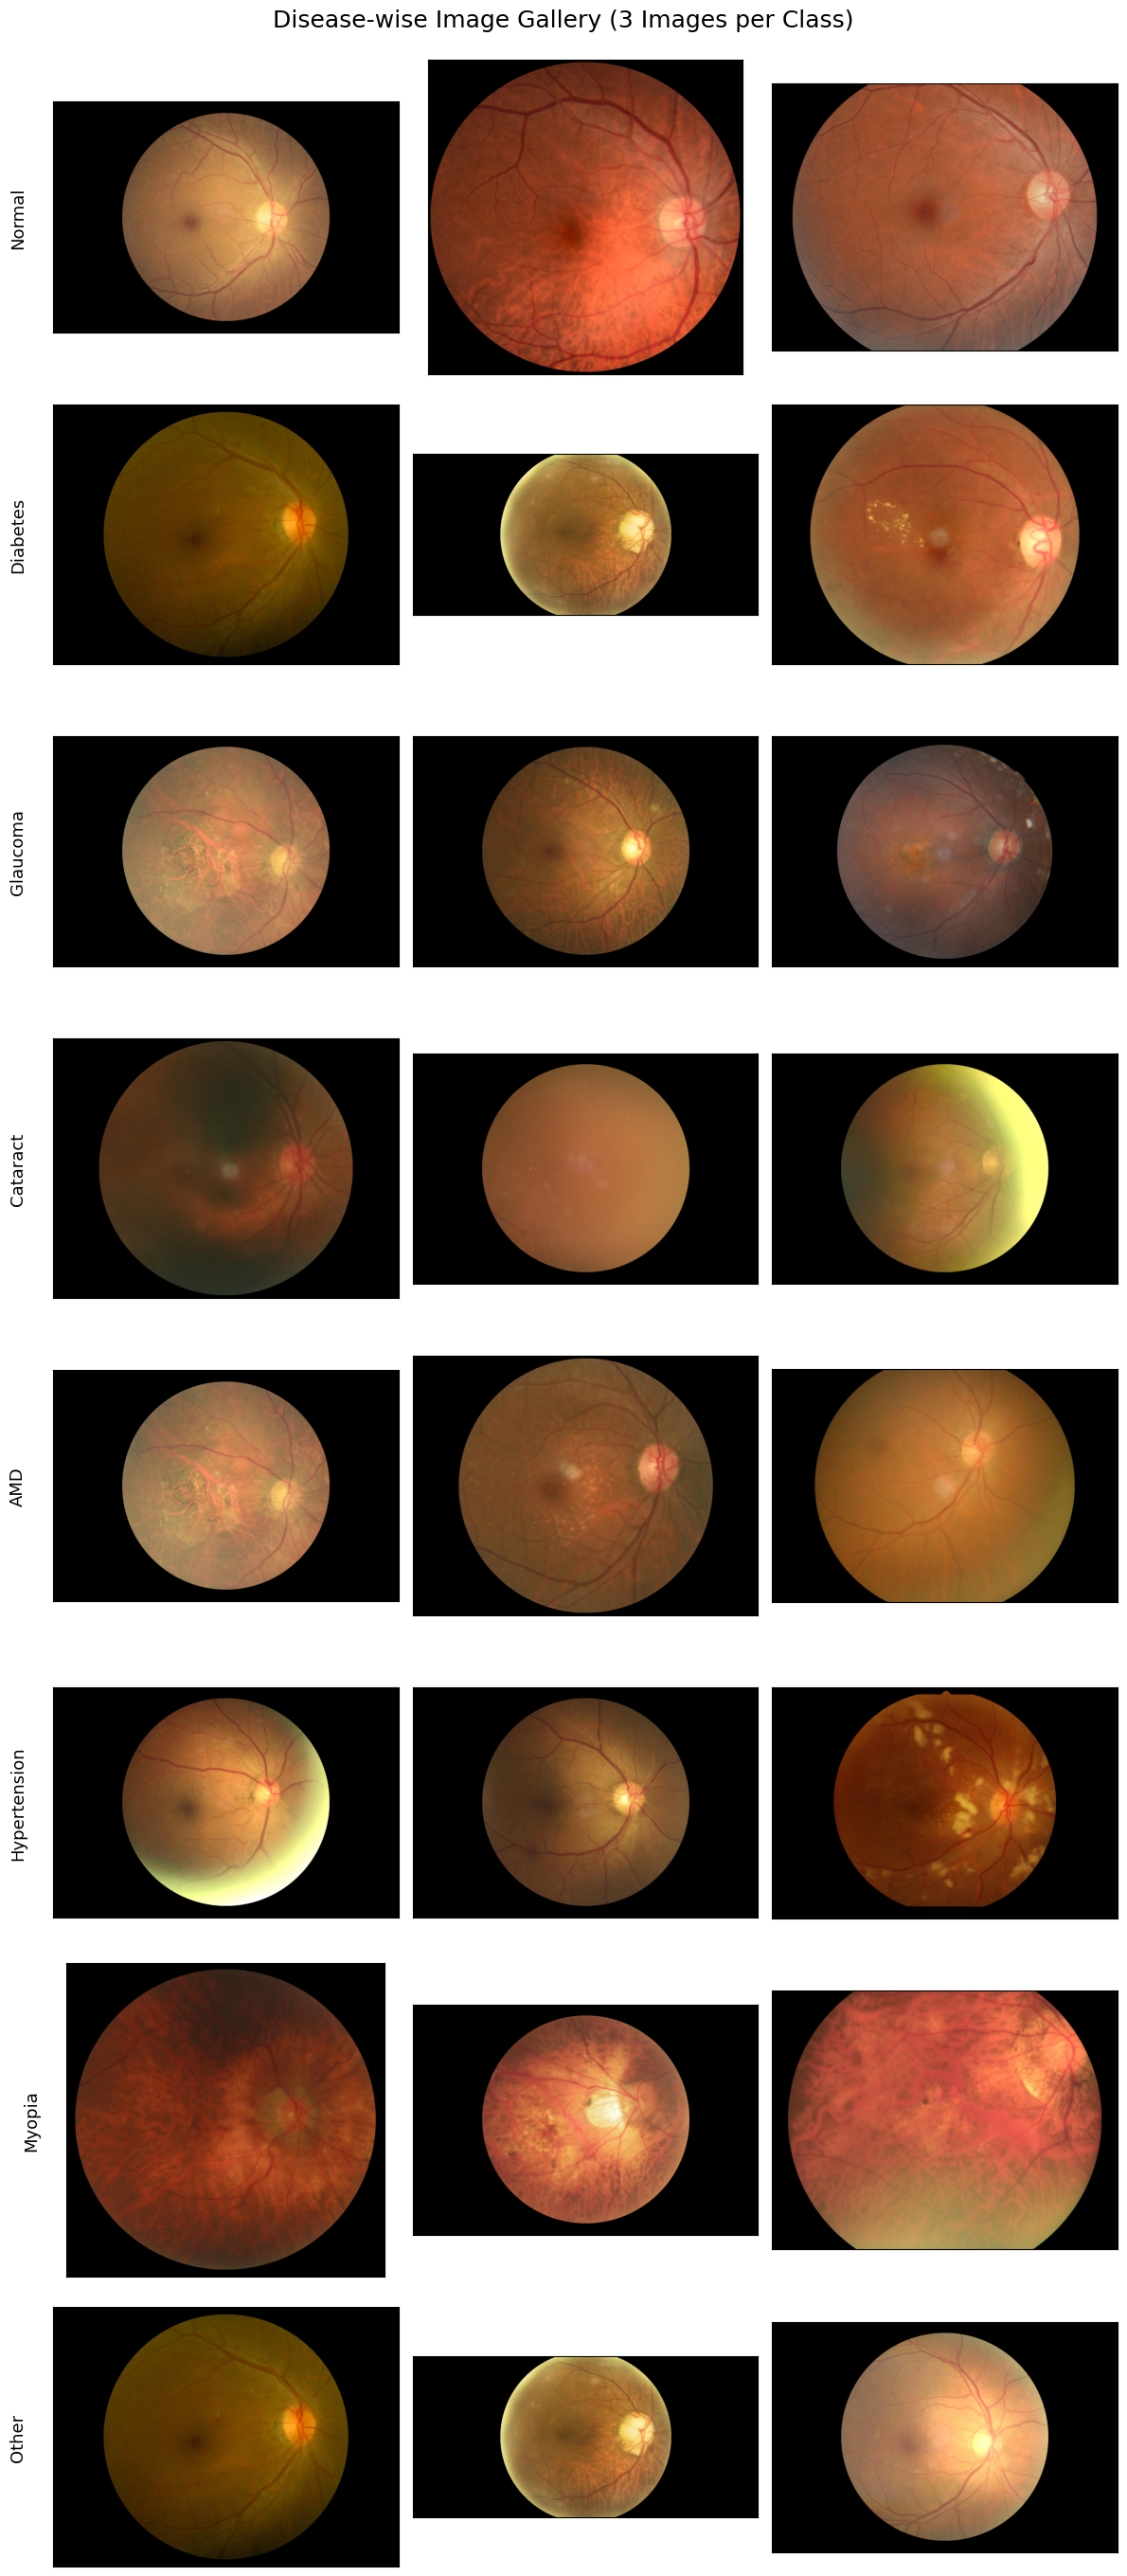

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# Disease labels
disease_map = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}

fig, axes = plt.subplots(8, 3, figsize=(12, 28))

for row, (col, disease_name) in enumerate(disease_map.items()):

    # Get all images belonging to this disease
    disease_samples = df[df[col] == 1]["filename"].head(3).tolist()

    for col_idx in range(3):

        ax = axes[row, col_idx]

        if col_idx < len(disease_samples):

            file = disease_samples[col_idx]
            img_path = os.path.join(TRAIN_DIR, file)

            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                ax.text(0.2, 0.5, "Image Not Found", fontsize=10)

        else:
            ax.text(0.2, 0.5, "No Image", fontsize=10)

        if col_idx == 0:
            ax.set_ylabel(disease_name, fontsize=13, rotation=90, labelpad=20)

        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Disease-wise Image Gallery (3 Images per Class)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
import os

print(len(os.listdir(TEST_DIR)))
print(sorted(os.listdir(TEST_DIR))[:10])

1000
['1000_left.jpg', '1000_right.jpg', '1001_left.jpg', '1001_right.jpg', '1002_left.jpg', '1002_right.jpg', '1003_left.jpg', '1003_right.jpg', '1004_left.jpg', '1004_right.jpg']


In [ ]:
test_files = set(os.listdir(TEST_DIR))
csv_files = set(df["filename"])

print("Common files:", len(test_files & csv_files))

Common files: 0


In [ ]:
import pandas as pd
import os

DATA_PATH = os.path.join(ROOT,"ODIR-5K","ODIR-5K", "data.xlsx")

data_df = pd.read_excel(DATA_PATH)

print(data_df.shape)
data_df.head()

(3500, 15)


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [ ]:
data_df[data_df["ID"] == 1000]

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O


In [ ]:
data_df[(data_df["ID"] >= 1000) & (data_df["ID"] <= 1499)]

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
994,1005,78,Female,1005_left.jpg,1005_right.jpg,macular hole,normal fundus,0,0,0,0,0,0,0,1
995,1006,64,Male,1006_left.jpg,1006_right.jpg,normal fundus,macular epiretinal membrane,0,0,0,0,0,0,0,1
996,1008,65,Male,1008_left.jpg,1008_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1
997,1010,63,Female,1010_left.jpg,1010_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
998,1011,36,Male,1011_left.jpg,1011_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,1494,38,Male,1494_left.jpg,1494_right.jpg,glaucoma,normal fundus,0,0,1,0,0,0,0,0
1333,1495,64,Female,1495_left.jpg,1495_right.jpg,glaucoma,glaucoma,0,0,1,0,0,0,0,0
1334,1496,31,Female,1496_left.jpg,1496_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy，glaucoma,0,1,1,0,0,0,0,0
1335,1497,54,Male,1497_left.jpg,1497_right.jpg,glaucoma,glaucoma,0,0,1,0,0,0,0,0


In [ ]:
test_records = data_df[(data_df["ID"] >= 1000) & (data_df["ID"] <= 1499)]

print("Rows found:", len(test_records))
test_records.head(10)

Rows found: 343


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
994,1005,78,Female,1005_left.jpg,1005_right.jpg,macular hole,normal fundus,0,0,0,0,0,0,0,1
995,1006,64,Male,1006_left.jpg,1006_right.jpg,normal fundus,macular epiretinal membrane,0,0,0,0,0,0,0,1
996,1008,65,Male,1008_left.jpg,1008_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1
997,1010,63,Female,1010_left.jpg,1010_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
998,1011,36,Male,1011_left.jpg,1011_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
999,1012,56,Female,1012_left.jpg,1012_right.jpg,drusen,pathological myopia,0,0,0,0,0,0,1,1
1000,1013,66,Female,1013_left.jpg,1013_right.jpg,normal fundus,macular epiretinal membrane，drusen,0,0,0,0,0,0,0,1
1001,1014,70,Female,1014_left.jpg,1014_right.jpg,retinal pigmentation,normal fundus,0,0,0,0,0,0,0,1
1002,1015,53,Female,1015_left.jpg,1015_right.jpg,drusen,drusen,0,0,0,0,0,0,0,1
1003,1016,62,Female,1016_left.jpg,1016_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1


In [ ]:
test_filenames = os.listdir(TEST_DIR)

left_matches = data_df[data_df["Left-Fundus"].isin(test_filenames)]
right_matches = data_df[data_df["Right-Fundus"].isin(test_filenames)]

print("Left matches :", len(left_matches))
print("Right matches:", len(right_matches))

Left matches : 0
Right matches: 0


##Splitting Dataset (70/15/15)

Disease columns

In [ ]:
# MULTI-LABEL DISEASE COLUMNS

label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# These remain as 8 independent binary disease labels.
# DO NOT collapse them into one "label" column.

print("Disease columns:")
print(label_cols)

print("\nMulti-label examples:")
print(df[['filename'] + label_cols].head())

Disease columns:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

Multi-label examples:
      filename  N  D  G  C  A  H  M  O
0  0_right.jpg  0  0  0  1  0  0  0  0
1  1_right.jpg  1  0  0  0  0  0  0  0
2  2_right.jpg  0  1  0  0  0  0  0  1
3  4_right.jpg  0  1  0  0  0  0  0  1
4  5_right.jpg  0  1  0  0  0  0  0  0



Patient / Eye structure Check


In [ ]:

# Work only with the images represented in full_df
# The actual images will later be loaded from PREPROCESS_DIR.

df['eye'] = df['filename'].str.extract(
    r'_(left|right)\.jpg$'
)

print("Total image records:", len(df))
print("Unique patients:", df['ID'].nunique())

print("\nEye distribution:")
print(df['eye'].value_counts())

# Count the eyes available for each patient
eye_counts = df.groupby('ID')['eye'].agg(
    lambda x: set(x)
)

print("\nPatient eye availability:")
print(
    eye_counts.apply(
        lambda x:
            'Both' if x == {'left', 'right'}
            else 'Right only' if x == {'right'}
            else 'Left only' if x == {'left'}
            else 'Unknown'
    ).value_counts()
)

Total image records: 6392
Unique patients: 3358

Eye distribution:
eye
left     3198
right    3194
Name: count, dtype: int64

Patient eye availability:
eye
Both          3034
Left only      164
Right only     160
Name: count, dtype: int64



Check preprocessed image quality



In [ ]:
PREPROCESS_DIR = os.path.join(
    ROOT,
    "preprocessed_images"
)

preprocessed_files = set(
    os.listdir(PREPROCESS_DIR)
)

df['preprocessed_exists'] = df['filename'].isin(
    preprocessed_files
)

print(
    "Records with preprocessed images:",
    df['preprocessed_exists'].sum()
)

print(
    "Records missing preprocessed images:",
    (~df['preprocessed_exists']).sum()
)

Records with preprocessed images: 6392
Records missing preprocessed images: 0


 CREATE PATIENT-LEVEL RECORDS

In [ ]:

import os
import pandas as pd

# Our 8 independent disease labels
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


# ------------------------------------------------------------
# 1. Determine whether each image is RIGHT or LEFT eye
# ------------------------------------------------------------
# filenames look like:
#     0_right.jpg
#     0_left.jpg
#
# We use the filename already present in full_df.
df['eye'] = df['filename'].str.extract(
    r'_(left|right)\.jpg$'
)


# Check that every image was successfully identified
print("Eye identification:")
print(df['eye'].value_counts(dropna=False))

print("\nImages with unknown eye:")
print(df['eye'].isna().sum())


# ------------------------------------------------------------
# 2. Create the actual PREPROCESSED image path
# ------------------------------------------------------------
# IMPORTANT:
# These are the images that our model will actually use.
# We are NOT using the original ODIR images.

df['image_path'] = df['filename'].apply(
    lambda x: os.path.join(PREPROCESS_DIR, x)
)


# ------------------------------------------------------------
# 3. Create separate RIGHT and LEFT dataframes
# ------------------------------------------------------------

right_df = df[df['eye'] == 'right'].copy()
left_df = df[df['eye'] == 'left'].copy()


# ------------------------------------------------------------
# 4. Keep only information needed for patient-level records
# ------------------------------------------------------------

right_df = right_df[
    ['ID', 'image_path'] + label_cols
].copy()

left_df = left_df[
    ['ID', 'image_path']
].copy()


# Rename image columns
right_df = right_df.rename(
    columns={
        'image_path': 'right_image'
    }
)

left_df = left_df.rename(
    columns={
        'image_path': 'left_image'
    }
)


# ------------------------------------------------------------
# 5. Merge RIGHT + LEFT using patient ID
# ------------------------------------------------------------

patient_df = pd.merge(
    right_df,
    left_df,
    on='ID',
    how='outer'
)


# Rename ID for clarity
patient_df = patient_df.rename(
    columns={
        'ID': 'patient_id'
    }
)


# ------------------------------------------------------------
# 6. Arrange columns neatly
# ------------------------------------------------------------

patient_df = patient_df[
    [
        'patient_id',
        'right_image',
        'left_image'
    ] + label_cols
]


# ------------------------------------------------------------
# 7. Sort by patient ID
# ------------------------------------------------------------

patient_df = patient_df.sort_values(
    'patient_id'
).reset_index(drop=True)


# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("Patient-level dataframe created!")
print("--------------------------------")

print("Number of patients:", len(patient_df))
print("Number of columns:", len(patient_df.columns))

display(patient_df.head(10))

Eye identification:
eye
left     3198
right    3194
Name: count, dtype: int64

Images with unknown eye:
0
Patient-level dataframe created!
--------------------------------
Number of patients: 3358
Number of columns: 11


,patient_id,right_image,left_image,N,D,G,C,A,H,M,O
0,0,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5,5,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7,7,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
8,8,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Verify Patient Level Eye Availability


In [ ]:


has_right = patient_df['right_image'].notna()
has_left = patient_df['left_image'].notna()


print("Patients with BOTH eyes:",
      (has_right & has_left).sum())

print("Patients with RIGHT eye only:",
      (has_right & ~has_left).sum())

print("Patients with LEFT eye only:",
      (~has_right & has_left).sum())

print("Patients with NO eyes:",
      (~has_right & ~has_left).sum())


print("\nTotal patients:",
      len(patient_df))


# ------------------------------------------------------------
# Verify that all existing paths point to real preprocessed
# images
# ------------------------------------------------------------

right_exists = patient_df['right_image'].dropna().apply(
    os.path.exists
)

left_exists = patient_df['left_image'].dropna().apply(
    os.path.exists
)

print("\nMissing RIGHT preprocessed files:",
      (~right_exists).sum())

print("Missing LEFT preprocessed files:",
      (~left_exists).sum())

Patients with BOTH eyes: 3034
Patients with RIGHT eye only: 160
Patients with LEFT eye only: 164
Patients with NO eyes: 0

Total patients: 3358

Missing RIGHT preprocessed files: 0
Missing LEFT preprocessed files: 0



 Check Missing Multi label Target



In [ ]:
print("Missing values in disease labels:")
print(patient_df[label_cols].isna().sum())

print("\nPatients with at least one missing disease label:")

missing_label_mask = patient_df[label_cols].isna().any(axis=1)

print(
    "Number of patients:",
    missing_label_mask.sum()
)

display(
    patient_df.loc[
        missing_label_mask,
        ['patient_id', 'right_image', 'left_image'] + label_cols
    ].head(20)
)

Missing values in disease labels:
N    164
D    164
G    164
C    164
A    164
H    164
M    164
O    164
dtype: int64

Patients with at least one missing disease label:
Number of patients: 164


,patient_id,right_image,left_image,N,D,G,C,A,H,M,O
3,3,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,22,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,25,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,39,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,41,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,59,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,63,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,69,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,70,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,92,NaN,/content/drive/My Drive/Eye Disease/Dataset/pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 Check Complete vs Incomplete label records


In [ ]:
complete_labels = patient_df[label_cols].notna().all(axis=1)

print("Patients with complete labels:", complete_labels.sum())
print("Patients with missing labels:", (~complete_labels).sum())

Patients with complete labels: 3194
Patients with missing labels: 164


Check original labels for left only patients



In [ ]:
left_only_ids = patient_df.loc[
    patient_df['right_image'].isna() &
    patient_df['left_image'].notna(),
    'patient_id'
]

print("Number of left-only patients:", len(left_only_ids))

# Look at the ORIGINAL full_df rows for these patients
left_only_original = df[
    df['ID'].isin(left_only_ids)
].copy()

display(
    left_only_original[
        ['ID', 'filename'] + label_cols
    ].head(20)
)

Number of left-only patients: 164


,ID,filename,N,D,G,C,A,H,M,O
3196,3,3_left.jpg,0,0,0,0,0,0,0,1
3213,22,22_left.jpg,0,1,0,0,0,0,0,1
3216,25,25_left.jpg,0,0,0,0,0,0,0,1
3227,39,39_left.jpg,0,0,0,0,0,0,1,0
3229,41,41_left.jpg,0,1,0,0,0,0,0,1
3245,59,59_left.jpg,0,0,0,0,0,0,0,1
3249,63,63_left.jpg,0,0,0,0,0,0,0,1
3254,69,69_left.jpg,0,0,0,0,0,0,0,1
3255,70,70_left.jpg,0,0,0,0,0,0,0,1
3271,92,92_left.jpg,0,0,0,0,0,0,0,1


In [ ]:
# Check whether the original full_df actually has labels
# for all left-only patients.

left_only_label_check = (
    left_only_original
    .groupby('ID')[label_cols]
    .first()
)

print("Left-only patients with complete labels:")
print(
    left_only_label_check.notna().all(axis=1).sum()
)

print("Left-only patients with missing labels:")
print(
    left_only_label_check.isna().any(axis=1).sum()
)

Left-only patients with complete labels:
164
Left-only patients with missing labels:
0


 REBUILD PATIENT-LEVEL DATAFRAME CORRECTLY


In [ ]:
# ------------------------------------------------------------
# 1. Create a patient-level label table
# ------------------------------------------------------------
# We take the disease labels independently of eye availability.
# Therefore left-only patients will NOT lose their labels.

patient_labels = (
    df.groupby('ID')[label_cols]
      .first()
      .reset_index()
)


# ------------------------------------------------------------
# 2. Create RIGHT-eye image table
# ------------------------------------------------------------

right_df = df[df['eye'] == 'right'][[
    'ID',
    'image_path'
]].copy()

right_df = right_df.rename(
    columns={
        'image_path': 'right_image'
    }
)


# ------------------------------------------------------------
# 3. Create LEFT-eye image table
# ------------------------------------------------------------

left_df = df[df['eye'] == 'left'][[
    'ID',
    'image_path'
]].copy()

left_df = left_df.rename(
    columns={
        'image_path': 'left_image'
    }
)


# ------------------------------------------------------------
# 4. Start from ALL patients
# ------------------------------------------------------------

patient_df = patient_labels.copy()


# Add right-eye images
patient_df = patient_df.merge(
    right_df,
    on='ID',
    how='left'
)


# Add left-eye images
patient_df = patient_df.merge(
    left_df,
    on='ID',
    how='left'
)


# ------------------------------------------------------------
# 5. Rename patient ID
# ------------------------------------------------------------

patient_df = patient_df.rename(
    columns={
        'ID': 'patient_id'
    }
)


# ------------------------------------------------------------
# 6. Arrange columns
# ------------------------------------------------------------

patient_df = patient_df[
    [
        'patient_id',
        'right_image',
        'left_image'
    ] + label_cols
]


# ------------------------------------------------------------
# 7. Sort patients
# ------------------------------------------------------------

patient_df = patient_df.sort_values(
    'patient_id'
).reset_index(drop=True)


print("Patient-level dataframe rebuilt!")
print("--------------------------------")
print("Number of patients:", len(patient_df))
print("Number of columns:", len(patient_df.columns))

display(patient_df.head(10))

NameError: name 'df' is not defined

FINAL PATIENT-LEVEL VERIFICATION

In [ ]:
has_right = patient_df['right_image'].notna()
has_left = patient_df['left_image'].notna()

print("Patients with BOTH eyes:",
      (has_right & has_left).sum())

print("Patients with RIGHT eye only:",
      (has_right & ~has_left).sum())

print("Patients with LEFT eye only:",
      (~has_right & has_left).sum())

print("Patients with NO eyes:",
      (~has_right & ~has_left).sum())

print("\nTotal patients:",
      len(patient_df))


# ------------------------------------------------------------
# Check disease-label completeness
# ------------------------------------------------------------

missing_labels = patient_df[label_cols].isna().any(axis=1)

print("\nPatients with missing disease labels:",
      missing_labels.sum())


# ------------------------------------------------------------
# Check preprocessed image paths
# ------------------------------------------------------------

right_exists = patient_df['right_image'].dropna().apply(
    os.path.exists
)

left_exists = patient_df['left_image'].dropna().apply(
    os.path.exists
)

print("\nMissing RIGHT preprocessed files:",
      (~right_exists).sum())

print("Missing LEFT preprocessed files:",
      (~left_exists).sum())

Patients with BOTH eyes: 3034
Patients with RIGHT eye only: 160
Patients with LEFT eye only: 164
Patients with NO eyes: 0

Total patients: 3358

Patients with missing disease labels: 0

Missing RIGHT preprocessed files: 0
Missing LEFT preprocessed files: 0



 SAVE CLEAN PATIENT-LEVEL DATAFRAME



In [ ]:

# Create a copy so we don't modify patient_df itself
patient_df_save = patient_df.copy()

# Convert absolute paths into filenames only.
# The notebook can reconstruct the full path using PREPROCESS_DIR.
patient_df_save['right_filename'] = patient_df_save['right_image'].apply(
    lambda x: os.path.basename(x) if pd.notna(x) else None
)

patient_df_save['left_filename'] = patient_df_save['left_image'].apply(
    lambda x: os.path.basename(x) if pd.notna(x) else None
)

# Remove machine-specific absolute paths
patient_df_save = patient_df_save.drop(
    columns=['right_image', 'left_image']
)

# Put filenames near patient_id
patient_df_save = patient_df_save[
    ['patient_id', 'right_filename', 'left_filename'] + label_cols
]

# Save
PATIENT_CSV = os.path.join(
    ROOT,
    'patient_level_df.csv'
)

patient_df_save.to_csv(
    PATIENT_CSV,
    index=False
)

print("Saved patient-level dataframe:")
print(PATIENT_CSV)

print("\nShape:", patient_df_save.shape)

display(patient_df_save.head(10))

Saved patient-level dataframe:
/content/drive/My Drive/Eye Disease/Dataset/patient_level_df.csv

Shape: (3358, 11)


,patient_id,right_filename,left_filename,N,D,G,C,A,H,M,O
0,0,0_right.jpg,0_left.jpg,0,0,0,1,0,0,0,0
1,1,1_right.jpg,1_left.jpg,1,0,0,0,0,0,0,0
2,2,2_right.jpg,None,0,1,0,0,0,0,0,1
3,3,None,3_left.jpg,0,0,0,0,0,0,0,1
4,4,4_right.jpg,4_left.jpg,0,1,0,0,0,0,0,1
5,5,5_right.jpg,5_left.jpg,0,1,0,0,0,0,0,0
6,6,6_right.jpg,6_left.jpg,0,1,0,0,0,0,0,1
7,7,7_right.jpg,7_left.jpg,0,1,0,0,0,0,0,1
8,8,8_right.jpg,8_left.jpg,1,0,0,0,0,0,0,0
9,9,9_right.jpg,9_left.jpg,0,0,0,0,0,0,0,1



## PATIENT-LEVEL TRAIN / VALIDATION / TEST SPLIT


In [ ]:


from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Get unique patient IDs
# ------------------------------------------------------------

patient_ids = patient_df['patient_id'].values

print("Total patients:", len(patient_ids))


# ------------------------------------------------------------
# 2. First split: 70% TRAIN, 30% TEMP
# ------------------------------------------------------------

train_ids, temp_ids = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)


# ------------------------------------------------------------
# 3. Second split: TEMP → 15% VALIDATION + 15% TEST
# ------------------------------------------------------------

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    shuffle=True
)


# ------------------------------------------------------------
# 4. Create the actual dataframes
# ------------------------------------------------------------

train_df = patient_df[
    patient_df['patient_id'].isin(train_ids)
].copy()

val_df = patient_df[
    patient_df['patient_id'].isin(val_ids)
].copy()

test_df = patient_df[
    patient_df['patient_id'].isin(test_ids)
].copy()


# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# ------------------------------------------------------------
# 5. Display split sizes
# ------------------------------------------------------------

print("\nPATIENT-LEVEL SPLIT")
print("-------------------")

print("Training patients:   ", len(train_df))
print("Validation patients: ", len(val_df))
print("Test patients:       ", len(test_df))

print("\nTotal:",
      len(train_df) + len(val_df) + len(test_df))
print(df.head())

NameError: name 'patient_df' is not defined


VERIFY NO PATIENT LEAKAGE


In [ ]:


train_set = set(train_df['patient_id'])
val_set = set(val_df['patient_id'])
test_set = set(test_df['patient_id'])


print("Train ∩ Validation:",
      len(train_set & val_set))

print("Train ∩ Test:",
      len(train_set & test_set))

print("Validation ∩ Test:",
      len(val_set & test_set))


# Final check
assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("\n✅ No patient appears in more than one split.")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✅ No patient appears in more than one split.



##### CHECK EYE AVAILABILITY IN EACH PATIENT SPLIT



In [ ]:

def summarize_eye_availability(dataframe, split_name):

    has_right = dataframe['right_image'].notna()
    has_left = dataframe['left_image'].notna()

    both = (has_right & has_left).sum()
    right_only = (has_right & ~has_left).sum()
    left_only = (~has_right & has_left).sum()

    print(f"\n{split_name}")
    print("-" * len(split_name))
    print("Both eyes:     ", both)
    print("Right only:    ", right_only)
    print("Left only:     ", left_only)
    print("Total patients:", len(dataframe))


summarize_eye_availability(train_df, "TRAIN")
summarize_eye_availability(val_df, "VALIDATION")
summarize_eye_availability(test_df, "TEST")


TRAIN
-----
Both eyes:      2141
Right only:     109
Left only:      100
Total patients: 2350

VALIDATION
----------
Both eyes:      438
Right only:     32
Left only:      34
Total patients: 504

TEST
----
Both eyes:      455
Right only:     19
Left only:      30
Total patients: 504



###### SAVE PATIENT-LEVEL SPLIT DATAFRAMES


In [ ]:


def make_portable(df):
    """Remove machine-specific absolute image paths."""

    result = df.copy()

    result['right_filename'] = result['right_image'].apply(
        lambda x: os.path.basename(x) if pd.notna(x) else None
    )

    result['left_filename'] = result['left_image'].apply(
        lambda x: os.path.basename(x) if pd.notna(x) else None
    )

    result = result.drop(
        columns=['right_image', 'left_image']
    )

    result = result[
        ['patient_id', 'right_filename', 'left_filename'] + label_cols
    ]

    return result


train_save = make_portable(train_df)
val_save = make_portable(val_df)
test_save = make_portable(test_df)


train_save.to_csv(
    os.path.join(ROOT, 'train_patient_df.csv'),
    index=False
)

val_save.to_csv(
    os.path.join(ROOT, 'val_patient_df.csv'),
    index=False
)

test_save.to_csv(
    os.path.join(ROOT, 'test_patient_df.csv'),
    index=False
)


print("Saved:")
print("✓ train_patient_df.csv")
print("✓ val_patient_df.csv")
print("✓ test_patient_df.csv")

Saved:
✓ train_patient_df.csv
✓ val_patient_df.csv
✓ test_patient_df.csv



 FINAL DATASET INTEGRITY CHECK



In [ ]:
print("========== FINAL CHECK ==========\n")

# Patient counts
assert len(train_df) == 2350
assert len(val_df) == 504
assert len(test_df) == 504

# Total patients
assert (
    len(train_df) +
    len(val_df) +
    len(test_df)
) == 3358

# No patient overlap
assert len(set(train_df.patient_id) &
           set(val_df.patient_id)) == 0

assert len(set(train_df.patient_id) &
           set(test_df.patient_id)) == 0

assert len(set(val_df.patient_id) &
           set(test_df.patient_id)) == 0

# No missing labels
assert train_df[label_cols].isna().sum().sum() == 0
assert val_df[label_cols].isna().sum().sum() == 0
assert test_df[label_cols].isna().sum().sum() == 0

# No patient without an eye
assert (
    train_df[['right_image', 'left_image']].notna().any(axis=1).all()
)

assert (
    val_df[['right_image', 'left_image']].notna().any(axis=1).all()
)

assert (
    test_df[['right_image', 'left_image']].notna().any(axis=1).all()
)

print("✓ 3358 patients accounted for")
print("✓ 2350 train / 504 validation / 504 test")
print("✓ No patient leakage")
print("✓ No missing disease labels")
print("✓ Every patient has at least one eye")
print("✓ Patient-level split is fixed")
print("\n EYE DISEASE DATA PREPARATION COMPLETE")

========== FINAL CHECK ==========

✓ 3358 patients accounted for
✓ 2350 train / 504 validation / 504 test
✓ No patient leakage
✓ No missing disease labels
✓ Every patient has at least one eye
✓ Patient-level split is fixed

 EYE DISEASE DATA PREPARATION COMPLETE


In [ ]:
# from sklearn.model_selection import train_test_split

# train_df, temp_df = train_test_split(
#     df,
#     test_size=0.30,
#     random_state=42,
#     stratify=df['label']
# )

# print("Training images :", len(train_df))
# print("Temporary images:", len(temp_df))

In [ ]:
# val_df, test_df = train_test_split(
#     temp_df,
#     test_size=0.50,
#     random_state=42,
#     stratify=temp_df['label']
# )

# print("Training   :", len(train_df))
# print("Validation :", len(val_df))
# print("Testing    :", len(test_df))

Verifying Percentages

In [ ]:
# total = len(df)

# print(f"Train      : {len(train_df)} ({len(train_df)/total:.1%})")
# print(f"Validation : {len(val_df)/total:.1%})")
# print(f"Test       : {len(test_df)/total:.1%})")

Check Class Distribution



In [ ]:
# print("Original Dataset")
# print(df['label'].value_counts(normalize=True).sort_index())

# print("\nTraining")
# print(train_df['label'].value_counts(normalize=True).sort_index())

# print("\nValidation")
# print(val_df['label'].value_counts(normalize=True).sort_index())

# print("\nTesting")
# print(test_df['label'].value_counts(normalize=True).sort_index())

Visualize the Distribution

In [ ]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 4, figsize=(18,5))

# df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Original')
# train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Train')
# val_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Validation')
# test_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[3], title='Test')

# for ax in axes:
#     ax.set_xlabel("Disease")
#     ax.set_ylabel("Images")

# plt.tight_layout()
# plt.show()